## Microproyecto 2 - Clasificación de textos según ODS

Para este microproyecto se utilizaron algunos algoritmos clásicos de Machine Learning porque el objetivo era clasificar textos dentro de las 17 categorías de los Objetivos de Desarrollo Sostenible (ODS). Como el problema se basa en textos, primero teníamos que encontrar la forma de que el modelo pudiera “entenderlos/comprenderlos”.

Como los datos están en español y los modelos de Machine Learning no trabajan directamente con palabras sino con números, fue necesario convertir los textos en una representación numérica. Para hacer esto utilizamos el método de Bolsa de Palabras junto con TF-IDF, que nos permitió darle más importancia a las palabras relevantes dentro de cada texto.

Finalmente, utilizamos un modelo de clasificación supervisado llamado Logistic Regression. Para asegurarme de que el modelo realmente estuviera aprendiendo y no solo memorizando los datos, ajustamos los hiperparámetros utilizando validación cruzada. De esta manera pude obtener un modelo con mejor capacidad de generalización frente a datos nuevos.

Se utilizaron las librería Seaborn para la visualización de datos, especialmente para analizar la distribución de los ODS y construir la matriz de confusión.

También se utilizó NLTK (Natural Language Toolkit), una librería especializada en procesamiento de lenguaje natural. En particular, se descargaron las "stopwords" en español para eliminar palabras que no aportan significado relevante, como "el", "la", "de", etc. Esto ayuda a reducir la data irrelevante y mejorar la calidad de la representación textual.

## Importación librerias 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC

from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer


## Carga de datos

In [2]:
textos = pd.read_excel('textos.xlsx')
data = textos.copy()
data.head()

,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5


## Descripción de datos

El conjunto de datos está compuesto por textos en español y una etiqueta correspondiente a uno de los 17 Objetivos de Desarrollo Sostenible (ODS).

Cada fila contiene:
- Un texto (variable independiente).
- Un número que representa el ODS al que pertenece (variable objetivo).

Antes de entrenar el modelo, se verificó la distribución de las clases para analizar si existía desbalance.

## Distribución de clases

Se analiza la cantidad de textos por cada ODS para verificar si existe desbalance en el conjunto de datos, ya que un desbalance muy alto podría afectar el desempeño del modelo, favoreciendo las clases con mayor cantidad de ejemplos.

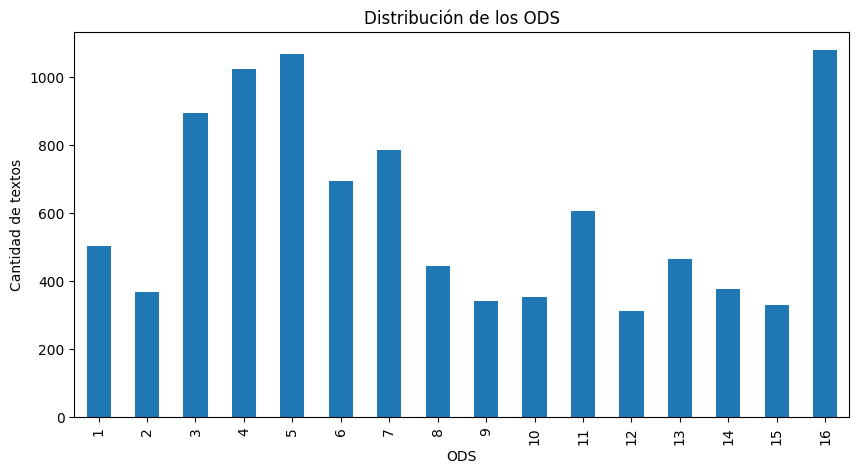

In [3]:
plt.figure(figsize=(10,5))
data['ODS'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribución de los ODS")
plt.xlabel("ODS")
plt.ylabel("Cantidad de textos")
plt.show()

## Tratamiento nulos y duplicados

Revisión de datos nulos y duplicados para el respectivo tratamiento. Al revisar que no hay ningun registro duplicado o nulo, no es necesario aplicar ningun tratamiento en este punto.

In [4]:
print(data.isnull().sum())
print(data.duplicated().sum())

textos    0
ODS       0
dtype: int64
0


## Creación método para pre procesamiento de texto

El pre procesamiento del texto es fundamental, ya que permite realizar una mejor interpretación de los datos a los algoritmos de machine learning a nivel general. Para el caso de uso se estan transformando los textos a minuscula y tokenizando usando una expresión regular que permite eliminar, números y simbolos que no aportan información importante al modelo (manteniendo tíldes), adicionalmente se eliminan las palabras de parada del español, las cuales no tienen un contenido semantico relevante para la interpretación de contenido del texto como lo son los conectores (de, el, la, etc) y finalmente la aplicación del stemming permite eliminar los afijos de las palabras, lo cual permite generar una agrupación de palabras similares que pueden permitir la asociación de conceptos generales. 

In [5]:
stop_words_es = set(stopwords.words('spanish'))
regex_tokenizer = RegexpTokenizer(r'[a-zA-ZáéíóúÁÉÍÓÚñÑ]+')
stemmer = SnowballStemmer('spanish')

def preprocesar_texto(texto):
    # Convertir a minúsculas
    texto = str(texto).lower()
    
    # Tokenizar directamente con Regex (nos saltamos word_tokenize)
    tokens = regex_tokenizer.tokenize(texto)
    
    # Quitar stopwords y aplicar stemming en un solo paso
    tokens_procesados = [stemmer.stem(word) for word in tokens if word not in stop_words_es]
    
    # Retornar texto unido
    return ' '.join(tokens_procesados)

## Separación variables entrenamiento y 

El dataset se dividió en 80% entrenamiento y 20% prueba.

Se utilizó el parámetro stratify=y para mantener la misma proporción de clases en ambos conjuntos, lo cual es importante debido al leve desbalance existente entre los ODS.

In [6]:
X = data['textos']
y = data['ODS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

## Pipeline de entrenamiento 

Se construyó un Pipeline base que integra todo el proceso en una sola estructura

1. TF-IDF: convierte los textos en vectores numéricos. 

2. TruncatedSVD: reduce la dimensionalidad del espacio vectorial.

3. Modelo de clasificación ( Regresion logistica, SVC ): Se plantean dos posibles algoritmos de clasificación, para comparar su desempeño a posteriori de aplicar la tecnica de reducción de dimensionalidad. 

De esta manera ejecutamos de forma ordenada y evitamos alguna fuga de información entre entrenamiento y prueba.

In [7]:
log_reg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
svc = SVC(random_state=42, class_weight='balanced')

pipeline_base = Pipeline([
    ('tfidf', TfidfVectorizer(preprocessor=preprocesar_texto, sublinear_tf=True)),
    ('svd', TruncatedSVD(random_state=42)),
    ('clf', log_reg)
])

## Búsqueda de hiperparámetros

Se utilizó RandomizedSearchCV para evaluar distintas combinaciones de los hiperparámetros de cada uno de los pasos nombrados a continuación. Se utilizó validación cruzada (cv=5) y como métrica principal F1-macro, ya que combina la precisión y el recall lo cual permite tener una perspectiva mas clara del rendimiento del clasificador y adicionalmente permite un tratamiento mas equilibrado entre clases a pesar del desbalance existente.

#### **TF-IDF**

TF-IDF permite asignar mayor peso a palabras que son importantes dentro de un texto.

Se plantea el uso de unigramas y la combinacion de unigramas con bigramas (ngram), para capturar tanto palabras individuales como combinaciones de dos palabras, mejorando la capacidad del modelo para diferenciar contextos. Adicionalmente se busqueda la mejor combinación para la eliminación de ruido en los terminos, tanto raros como demasiado comunes (min_df, max_df) que no aportan en la diferenciación de los tópicos.

Vale la pena mencionar que este objeto utiliza la función de pre-procesamiento construida anteriormente para realizar la representación de bolsa de palabras (BOW) y penalizar las palabras que son frecuentes en todos los textos, lo cual permite que palabras específicas de un tópico (ODS) tengan mayor relevancia dentro de la representación.

#### **Reducción de dimensionalidad con TruncatedSVD**

El resultado de la aplicación de bolsa de palabras con pesado TF-IDF genera una matriz dispersa (con muchos ceros), al aplicar esta tecnica se eliminan relaciones irrelevantes, manteniendo el conjunto de palabras o conceptos mas importantes para la representación, o mejor conocido como espacio latente. Se realizará la búsqueda de la cantidad de componentes necesarias para obtener un mejor resultado de clasificación.

#### **Modelo de clasificación: Logistic Regression vs SVC**

Se consideran los modelos de Logistic Regression y SVC.

El modelo de Logistic Regression es un modelo lineal, sencillo y robusto usado frecuentemente para la clasificación de texto, mientras por otro lado el modelo SVC es puede capturar relaciones mas complejas mediante kernels tanto lineales como no-lineales. Es interesante revisar el comportamiento de distintos kernels respecto al modelado de tópicos.

Para el ejercicio dada la naturaleza del balance de clases, se aplica class_weight='balanced' para compensar el leve desbalance presente y adicionalmente se realiza una búsqueda aleatoria de parámetros para encontrar el mejor algoritmo.

In [8]:
parametros_comunes = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [5, 10],
    'tfidf__max_df': [0.8, 0.9],
    'svd__n_components': [100, 200, 300],
    'clf__C': [0.1, 1.0, 10.0]
}

parametros_competencia = [
    {
        **parametros_comunes,
        'clf': [log_reg],
    },
    {
        **parametros_comunes,
        'clf': [svc],
        'clf__kernel': ['linear', 'rbf'] 
    }
]

busqueda = RandomizedSearchCV(
    estimator=pipeline_base,
    param_distributions=parametros_competencia  ,
    n_iter=20, 
    cv=5,
    scoring='f1_macro',
    n_jobs=-1, 
    random_state=42,
    verbose=10
)

In [9]:
busqueda.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"[{'clf': [LogisticRegre...ndom_state=42)], 'clf__C': [0.1, 1.0, ...], 'svd__n_components': [100, 200, ...], 'tfidf__max_df': [0.8, 0.9], ...}, {'clf': [SVC(class_wei...ndom_state=42)], 'clf__C': [0.1, 1.0, ...], 'clf__kernel': ['linear', 'rbf'], 'svd__n_components': [100, 200, ...], ...}]"
,n_iter,20
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,10
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


### Métricas de evaluación

Se utilizaron las siguientes métricas:

- Precision
- Recall
- F1-score
- Accuracy

Se prioriza F1-macro porque considera el desempeño promedio en todas las clases, siendo adecuada cuando existe desbalance entre categorías.

In [10]:

print("\n--- BÚSQUEDA COMPLETADA ---")
print(f"Mejor combinación de hiperparámetros encontrada:\n{busqueda.best_params_}")
print(f"Mejor F1-score (CV): {busqueda.best_score_:.4f}")

mejor_modelo = busqueda.best_estimator_
predicciones_finales = mejor_modelo.predict(X_test)

print(classification_report(y_test, predicciones_finales))


--- BÚSQUEDA COMPLETADA ---
Mejor combinación de hiperparámetros encontrada:
{'tfidf__ngram_range': (1, 2), 'tfidf__min_df': 5, 'tfidf__max_df': 0.9, 'svd__n_components': 300, 'clf__kernel': 'rbf', 'clf__C': 10.0, 'clf': SVC(class_weight='balanced', random_state=42)}
Mejor F1-score (CV): 0.8566
              precision    recall  f1-score   support

           1       0.85      0.81      0.83       101
           2       0.81      0.86      0.84        74
           3       0.94      0.93      0.94       179
           4       0.97      0.96      0.96       205
           5       0.91      0.94      0.93       214
           6       0.94      0.94      0.94       139
           7       0.92      0.93      0.93       158
           8       0.66      0.73      0.70        89
           9       0.72      0.83      0.77        69
          10       0.77      0.67      0.72        70
          11       0.85      0.84      0.85       122
          12       0.87      0.85      0.86        62


## Matriz de confusión

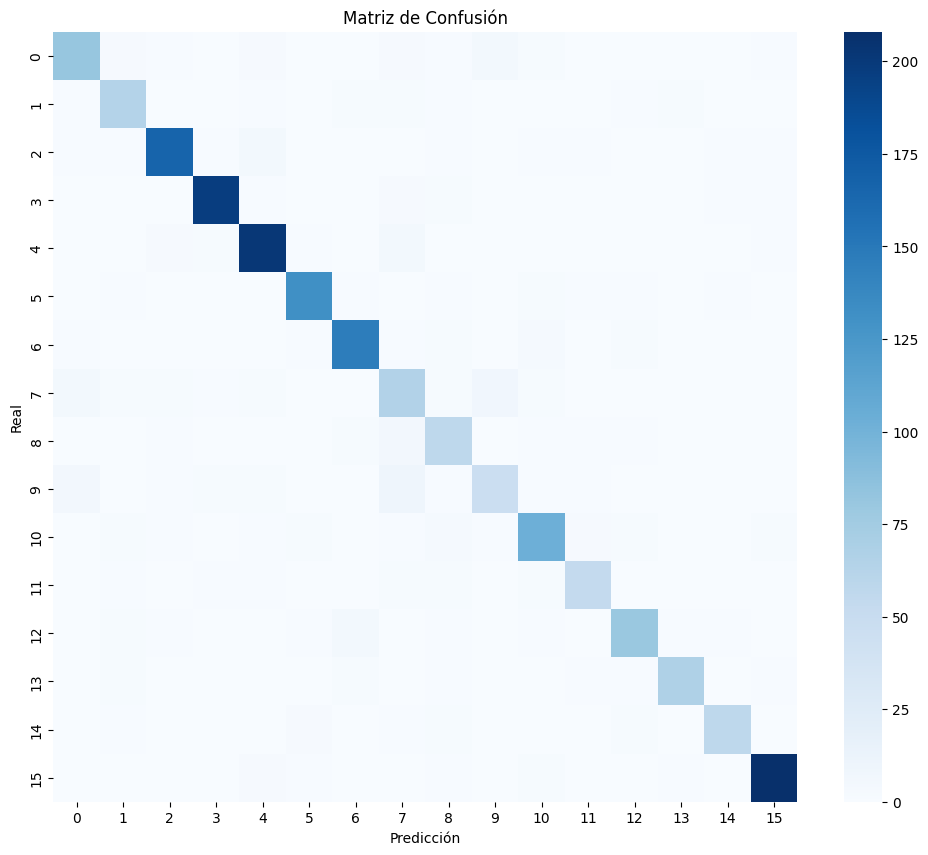

In [11]:
cm = confusion_matrix(y_test, predicciones_finales)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

## Conclusiones

- Se logró pre procesar y transformar con éxito diferentes textos en español a una representación vectorial usando bolsa de palabras con pesado tf-idf haciendo uso de bigramas, lo cual permitió que el modelo de clasificación aplicado fuera capaz de identificar relaciones entre palabras que resultaran relevantes en el contexto de los ODS y los 17 tópicos identificados. Así se configura la manera en que una técnica de aprendizaje supervisado puede emplear técnicas de aprendizaje no supervisado para hacer la representación de texto y mejorar la representación de la información inherente al mismo.

- La aplicación de SVD truncado para la reducción de la dimensionalidad, permitió la creación de un espacio latente donde se agruparon temas y conceptos similares, permitiendo que el clasificador tuviera mejor capacidad de discriminación frente a la estructura inherente a cada tópico.

- El uso de un pipeline automatizado garantizo la integridad de la información durante todo el proceso, preprocesando, vectorizando y aplicando reducción de dimensionalidad. Esto permitió identificar que el modelo SVC tiene una leve mejor capacidad para la clasificación de tópicos en el contexto del problema dado, una vez encontrados los hiperparámetros óptimos para el mismo.

- El desbalance de clases suele ser uno de los problemas mas frecuentes en el mundo del mahcine learning. Para el caso de estudio no fue la excepcion y se logró gestionar de forma exitosa haciendo uso de la métrica F1-Macro y el balanceo de clases como hiperparámetro, esto evidenciado en la matriz de confusion y métricas como la precisión que indican un buen desempeño del modelo tanto en clases mayoritarias como minoritarias.

- Las métricas finales, demuestran una capacidad importante de generalización del modelo, con un accuracy global del 89% asi como valores altos en las métricas para cada una de las clases. Estos resultados demuestran que el modelo es una herramienta con alta confiabilidad en la categorización automatica de documentos alineados a la Agenda 2030 para el desarrollo sostenible.

In [12]:
import joblib

# Suponiendo que 'busqueda' es el objeto de tu RandomizedSearchCV
modelo_final = busqueda.best_estimator_

# Guardar el pipeline completo (incluye preprocesamiento, TF-IDF, SVD y SVC)
joblib.dump(modelo_final, 'modelo_ods_final.pkl')

['modelo_ods_final.pkl']